In [ ]:
!pip install pmdarima
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
from pandas.tseries.offsets import CustomBusinessDay
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
%matplotlib inline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.0 MB/s eta 0:00:00


ValueError: mount failed

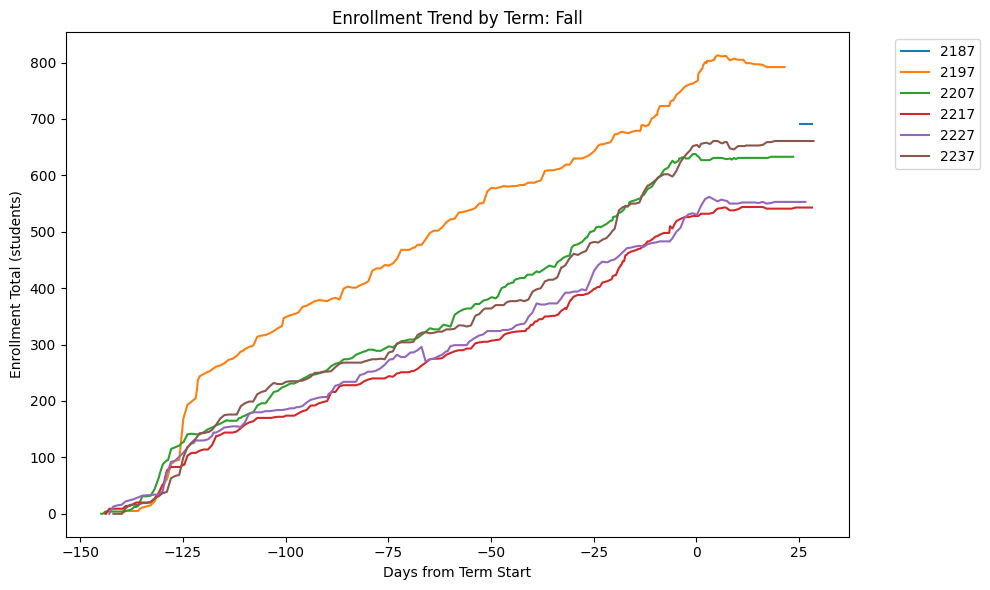

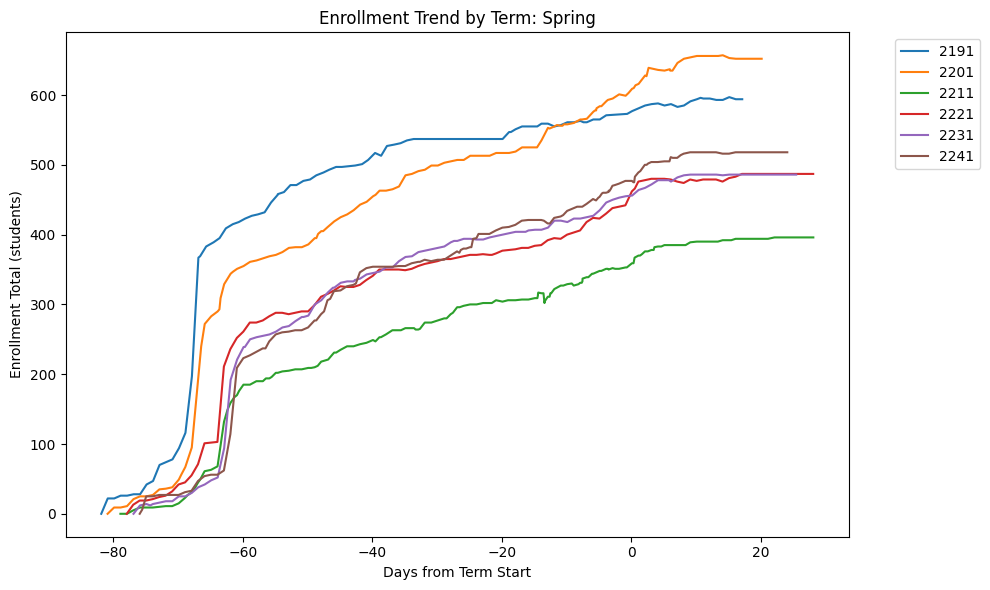

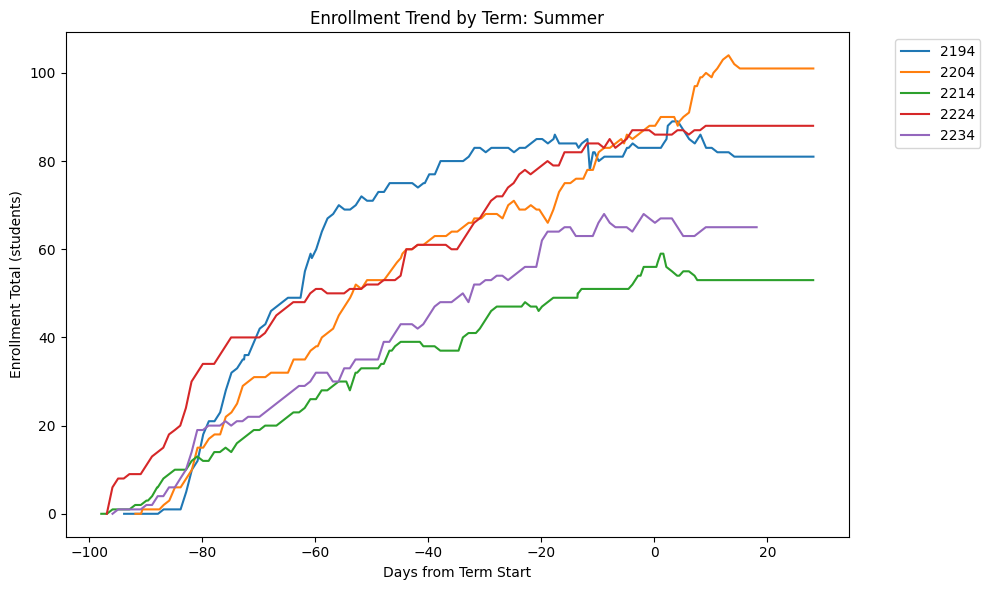

In [ ]:
# Define functions to process term codes, calculate term starts, load data, and plot results.
def inverse_term_code(term):
    seasons = {
        '1': 'Spring',
        '4': 'Summer',
        '7': 'Fall'
    }
    term_str = str(term)
    year = term_str[0] + ('0' if term_str[0] == '2' else '9') + term_str[1:3]
    return int(year), seasons[term_str[3]]

def term_starts(term):
    year, season = inverse_term_code(term)
    match season:
        case 'Fall':
            d = dt.date(year=year, month=9, day=1)
            if (day_of_week := d.weekday()) != 0:
                d += dt.timedelta(days=7-day_of_week)
            return pd.Timestamp(d - dt.timedelta(weeks=2))
        case 'Spring':
            d = dt.date(year=year, month=1, day=1)
            if (day_of_week := d.weekday()) != 0:
                d += dt.timedelta(days=7-day_of_week)
            d += dt.timedelta(weeks=2)
            return pd.Timestamp(d + dt.timedelta(days=1))
        case 'Summer':
            d = dt.date(year=year, month=6, day=1)
            if (day_of_week := d.weekday()) != 0:
                d += dt.timedelta(days=7-day_of_week)
            return pd.Timestamp(d)
        case _:
            raise ValueError(f"Unrecognized season={season}")

def plot_seasonal_enrollment(data, season):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=data, x='DaysFromTermStart', y='EnrollmentTotal', hue='Term', estimator=None)
    plt.xlabel('Days from Term Start')
    plt.ylabel('Enrollment Total (students)')
    plt.title(f'Enrollment Trend by Term: {season}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def load_and_process_data(file_paths):
    df = pd.DataFrame()
    for filename in file_paths:
        try:
            termdf = pd.read_parquet(filename)
            df = pd.concat([df, termdf], ignore_index=True)
        except Exception as e:
            print(f"Error processing file {filename}: {e}")
    df['TermStart'] = df['Term'].apply(term_starts)
    return df

def process_and_plot_enrollment(subject, catalog_number, df):
    course_df = df[(df['Subject'] == subject) & (df['CatalogNumber'] == str(catalog_number))].copy()
    course_df['DaysFromTermStart'] = (course_df['Timestamp'] - course_df['TermStart']).dt.total_seconds() / 86400.0
    grouped_df = course_df.groupby(by=['Term', 'CatalogNumber', 'DaysFromTermStart']) \
               .aggregate({'EnrollmentTotal': 'sum'}).reset_index()
    rt = grouped_df.pivot_table(
        index=['DaysFromTermStart'],
        columns=['Term'],
        values='EnrollmentTotal').reset_index().set_index('DaysFromTermStart')
    fall_df = grouped_df[grouped_df['Term'].apply(lambda x: str(x)[-1] == '7')]
    spring_df = grouped_df[grouped_df['Term'].apply(lambda x: str(x)[-1] == '1')]
    summer_df = grouped_df[grouped_df['Term'].apply(lambda x: str(x)[-1] == '4')]
    plot_seasonal_enrollment(fall_df, 'Fall')
    plot_seasonal_enrollment(spring_df, 'Spring')
    plot_seasonal_enrollment(summer_df, 'Summer')

# File paths to the Parquet files
file_paths = [
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2187.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2191.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2194.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2197.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2201.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2204.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2207.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2211.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2214.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2217.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2221.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2224.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2227.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2231.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2234.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2237.parquet',
    '/content/drive/MyDrive/ENROLLMENT DATA/all_cmr_math_2241.parquet',
]

# Load the data
df = load_and_process_data(file_paths)

# Example subject and catalog number
subject = 'MATH'  # Example subject
catalog_number = 1401  # Example catalog number

# Process and plot enrollment for the specified course
process_and_plot_enrollment(subject, catalog_number, df)

In [ ]:
def plot_seasonal_enrollment_interactive(grouped_df, season):
    # Create a line plot using Plotly Express. The data, axes, and line colors are defined.
    fig = px.line(grouped_df, x='WeeksFromTermStart', y='EnrollmentTotal', color='Term',
                  labels={'WeeksFromTermStart': 'Weeks from Term Start', 'EnrollmentTotal': 'Enrollment Total'},
                  title=f'Enrollment Trend for {season}', markers=True)

    # Update hover information to show detailed data when hovering over points on the graph.
    fig.update_traces(
        hovertemplate="<br>".join([
            "Term: %{color}",  # Displays the term of the data point
            "Enrollment Total: %{y}",  # Displays the enrollment total at the data point
            "Weeks from Term Start: %{x}",  # Displays weeks from term start
            "Timestamp: %{customdata}"  # Displays timestamp of the data collection
        ]),
        customdata=grouped_df['Timestamp_str']  # Custom data to display on hover
    )

    # Set titles for the x and y axes.
    fig.update_xaxes(title_text='Weeks from Term Start')
    fig.update_yaxes(title_text='Enrollment Total')

    # Update the layout to adjust legend title.
    fig.update_layout(legend_title_text='Term')

    # Display the plot.
    fig.show()

def process_and_plot_enrollment(subject, catalog_number, df):
    # Filter DataFrame for a specific subject and catalog number.
    course_df = df.loc[(df['Subject'] == subject) & (df['CatalogNumber'] == str(catalog_number))].copy()

    # Format Timestamp data to a string for easier readability in tooltips.
    course_df['Timestamp_str'] = course_df['Timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

    # Calculate the days from the term start to the timestamp.
    course_df['DaysFromTermStart'] = (course_df['Timestamp'] - course_df['TermStart']).dt.total_seconds() / 86400.0

    # Convert days to weeks for a broader time scale.
    course_df['WeeksFromTermStart'] = course_df['DaysFromTermStart'] / 7

    # Group by Term, CatalogNumber, and WeeksFromTermStart to summarize data.
    grouped_df = course_df.groupby(['Term', 'CatalogNumber', 'WeeksFromTermStart'], as_index=False) \
                          .agg({'EnrollmentTotal': 'sum', 'Timestamp_str': 'first'})

    # Loop through season codes to filter and plot data by season.
    for season_code, season_name in [('7', 'Fall'), ('1', 'Spring'), ('4', 'Summer')]:
        season_group_df = grouped_df[grouped_df['Term'].astype(str).str.endswith(season_code)]
        # Plot only if there is data for the season.
        if not season_group_df.empty:
            plot_seasonal_enrollment_interactive(season_group_df, season_name)


# Example usage of the process_and_plot_enrollment function
subject = 'MATH'  # Define the subject of interest.
catalog_number = 1401  # Define the catalog number of the course.

# Call the function to process and plot enrollment data.
process_and_plot_enrollment(subject, catalog_number, df)


# comment out this section

# To view other courses, simply chnage the input of the catalognumbe

# for example, rightnow we are viewing MATH 1491, if you wnant to chaneg to jMAth 3181, just switch out the Catlognumber for the desried course.

In [ ]:
try:
    # Convert 'StartDate' and 'Timestamp' to datetime
    df['StartDate'] = pd.to_datetime(df['StartDate'])
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    # Sort the data to prepare for grouping
    df = df.sort_values(['Subject', 'CatalogNumber', 'Section', 'StartDate', 'Timestamp'], ascending=[True, True, True, True, True])

    # Extract date from 'Timestamp' (removing time)
    df['Timestamp'] = df['Timestamp'].dt.date

    # Get the latest timestamp for each day for each section
    df_latest = df.groupby(['Subject', 'CatalogNumber', 'Section', 'StartDate', 'Timestamp'], as_index=False).last()

    # Group by Subject, CatalogNumber, and Timestamp, keeping unique section enrollments
    df_daily = df_latest.groupby(['Subject', 'CatalogNumber', 'StartDate', 'Timestamp'], as_index=False).agg({'EnrollmentTotal': 'sum'})

    # Save the DataFrame to a CSV file
    df_daily.to_csv('df_daily.csv', index=False)

    # Confirm successful execution
    print("The data processing and saving were completed successfully.")

except KeyError as e:
    print(f"Error: Column {e} not found in DataFrame. Please check the DataFrame and ensure all columns exist.")
    print("If this error persists, consider checking your data input or restarting the environment.")


The data processing and saving were completed successfully.


In [ ]:
try:
    # Convert 'StartDate' to datetime and ensure 'CatalogNumber' is an integer
    df_daily['StartDate'] = pd.to_datetime(df_daily['StartDate'])
    df_daily['CatalogNumber'] = df_daily['CatalogNumber'].astype(int)

    # Filter the dataset for MATH 1401 using the numeric 'CatalogNumber'
    specific_course = df_daily[
        (df_daily['Subject'] == 'MATH') &
        (df_daily['CatalogNumber'] == 1401)
    ]

    # Save the DataFrame to a CSV file
    specific_course.to_csv('specific_course.csv', index=False)

    if specific_course.empty:
        print("No data found for MATH 1401. Please check the dataset for correct entries.")
    else:
        print("Data successfully filtered for MATH 1401.")

except KeyError as e:
    print(f"Error: Column {e} not found in DataFrame. Please ensure all required columns ('Subject', 'CatalogNumber') are present.")
except Exception as e:
    print(f"An error occurred: {e}")

Data successfully filtered for MATH 1401.


In [ ]:
specific_course.head()

,Subject,CatalogNumber,StartDate,Timestamp,EnrollmentTotal
16786,MATH,1401,2018-08-20,2018-09-14,691
16787,MATH,1401,2018-08-20,2018-09-15,691
16788,MATH,1401,2018-08-20,2018-09-16,691
16789,MATH,1401,2018-08-20,2018-09-17,691
16790,MATH,1401,2019-01-22,2018-11-01,0


**Steps for Building the SARIMA:**

* **Step 1a Check for Stationarity:** Stationarity  means the statistical properties of the time series (mean, variance) remain constant over time. This step involves using visual plots and statistical tests, like the Augmented Dickey-Fuller (ADF) test, to determine if the time series data needs to be transformed to achieve stationarity. A stationary series is crucial for ARIMA modeling because the model assumes the underlying data does not change its behavior unpredictably over time.

* **Step 1b Differencing (If needed):**

* **Step 2 Check for Seasonality:** Seasonality refers to periodic fluctuations in the time series data, such as higher enrollment in fall and spring terms due to the academic calendar. We use seasonal decomposition methods to discern these regular patterns that repeat over known intervals. Identifying seasonality is important because it informs us whether to include seasonal terms in our modeling.

* **Step 3 Choose Model Type:** Based on whether we find seasonality or not, we choose between an ARIMA model for non-seasonal data or a SARIMA model for seasonal data. The ARIMA model is suitable for data without a seasonal component, while SARIMA can handle both non-seasonal and seasonal fluctuations.

* **Step 4 Determine Non-Seasonal Parameters (p, d, q):** We determine the number of autoregressive terms (p), the number of differencing needed to de-trend the data (d), and the number of moving average terms (q). The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots help in identifying these parameters. 'p' represents the effect of past values on current values, 'd' adjusts for trends, and 'q' captures the relationship between a time series and a lagged version of its errors.

* **Step 5 Determine Seasonal Parameters (P, D, Q, s):** Here, we identify the seasonal version of the non-seasonal parameters: seasonal autoregressive order (P), seasonal differencing (D), seasonal moving average order (Q), and the length of the seasonal cycle (s). These are akin to non-seasonal parameters but apply to the seasonal component of the data, allowing the model to account for regular patterns that repeat over specific intervals (like semesters or quarters).

* **Step 6 Split Data:** We separate the available data into a training set for developing the model and a testing set for evaluating its predictive performance. Typically, the data is split chronologically with a larger portion for training to ensure the model is trained on a comprehensive dataset.

* **Step 7 Build the SARIMA Model:** With the parameters identified, we specify and fit the SARIMA model using the training dataset. Fitting the model means estimating the model coefficients that best capture the patterns in the data.


* **Step 8 Model Fitting:** The SARIMA model is fine-tuned and validated on the training data to ensure that it converges, meaning the iterative process of finding the best coefficients successfully finds a stable solution.

* **Step 9 Model Diagnostics:** We analyze the residuals (the differences between our model's predictions and the actual data) to check for any patterns that might suggest the model is not capturing all the information in the data. Diagnostics can include examining residual plots, conducting statistical tests for normality, and assessing autocorrelation.

* **Step 10 Predictions:** We use the validated model to predict future values for the test dataset period. These predictions are compared against the actual data to assess the model's accuracy.

* **Step 11 Evaluation Metrics:** Specific statistical metrics, such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), are used to quantify the model's prediction error, providing a clear measure of its performance.

* **Step 12 Model Validation:** The model's predictions are scrutinized to ensure they are robust and consistent when compared to known outcomes. This step often involves using methods like walk-forward validation, where the model is repeatedly trained on rolling windows of the data to validate its performance over different time intervals.

* **Step 13 Parameter Tuning:** If the model's performance is not satisfactory, we return to the parameter determination steps to refine the model's settings, seeking to improve its predictive ability.

* **Step 14 Final Model:** Once the model demonstrates reliable performance, it is finalized by fitting it to the entire dataset. This maximizes the information the model has learned for making future forecasts.

* **Step 15 Forecasting:** The final model is used to make forecasts for future periods that go beyond the available data. These forecasts are accompanied by confidence intervals that provide a range within which we expect future values to fall.

* **Step 16 Deploy Model:** The final model is implemented in a practical setting, where it can be used by stakeholders to make informed decisions based on its forecasts.

* **Step 17 Monitor Performance:&& After deployment, the model's forecasts are continually monitored against actual outcomes. This ongoing evaluation allows for timely updates or adjustments to the model in response to new data or changing conditions.

**Step 1a-b: Checking for Stationarity and Applying Differencing if Necessary**

1. **ADF Statistic:** The ADF statistic is -4.9107. This value is significantly negative, which is crucial for the ADF test as it seeks to reject the null hypothesis that the series has a unit root. A more negative value here provides stronger evidence against the presence of a unit root in the series. (Note: A unit root in a time series signifies that the series is non-stationary. Specifically, a unit root means that the series will both persistently grow over time and its future values depend on the level of its past values, with a stochastic, or random, trend component. This characteristic implies that shocks to the time series have a permanent effect, causing the series to drift away rather than returning to a long-term mean. Time series with unit roots exhibit random walks and have unpredictable paths that make modeling and forecasting challenging.)

2. **p-Value:** The p-value obtained from the test is approximately $3.3\times10^{-5}5$ which is extremely low. In the context of hypothesis testing, a p-value less than 0.05 (5% significance level) typically indicates strong evidence against the null hypothesis. Here, the null hypothesis states that the series has a unit root, implying that it is non-stationary. The very small p-value strongly supports rejecting this hypothesis, suggesting that the series is stationary.

3. **Critical Value** These values provide thresholds at which the ADF statistic would have to fall below to reject the null hypothesis at certain confidence levels:

    **1% level:** -3.434

    **5% level:** -2.863

    **10% level:** -2.568

In this case, the ADF statistic of -4.9107 is more negative than all of these critical values, indicating rejection of the null hypothesis across the 1%, 5%, and 10% significance levels. This reinforces the conclusion of stationarity. Since the series is confirmed as stationary, there is no need to apply differencing. Differencing is a method used to transform a non-stationary series into a stationary one by removing the underlying trends and cycles. As the series is already stationary, further differencing could lead to data loss or overfitting, which could distort analysis and predictive modeling.

In [ ]:
# Function to perform ADF test and provide detailed results
def perform_adf_test(series):
    try:
        adf_result = adfuller(series, autolag='AIC')
        print("ADF Statistic:", adf_result[0])
        print("p-value:", adf_result[1])
        print("Critical Values:")
        for key, value in adf_result[4].items():
            print(f'    {key}: {value:.3f}')
        return adf_result[1]
    except Exception as e:
        print(f"An error occurred during ADF testing: {e}")
        return None

try:
    # Initial check for stationarity
    initial_p_value = perform_adf_test(specific_course['EnrollmentTotal'])

    if initial_p_value is not None:
        # Initialize a counter for the number of differencing operations
        diff_counter = 0
        max_diff = 2  # Maximum number of differencing allowed

        # Perform differencing if necessary and re-test stationarity
        if initial_p_value >= 0.05:
            while initial_p_value >= 0.05 and diff_counter < max_diff:
                specific_course['EnrollmentTotal'] = specific_course['EnrollmentTotal'].diff().dropna()
                initial_p_value = perform_adf_test(specific_course['EnrollmentTotal'])
                diff_counter += 1
                if initial_p_value < 0.05:
                    print("The series is stationary. No further differencing is needed.")
                else:
                    print(f"Differencing applied {diff_counter} time(s). Series is still not stationary.")
            if initial_p_value >= 0.05:
                print("Series did not become stationary after the maximum allowed differencing.")
        else:
            print("No differencing required as the series is already stationary.")
            print("This implies that the time series does not have a unit root, and mean and variance are constant over time.")
except KeyError:
    print("Error: Ensure 'EnrollmentTotal' column exists in the dataset.")
except pd.errors.EmptyDataError:
    print("Error: The dataset is empty. Check the data input.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


ADF Statistic: -4.910709290173978
p-value: 3.323852670670317e-05
Critical Values:
    1%: -3.434
    5%: -2.863
    10%: -2.568
No differencing required as the series is already stationary.
This implies that the time series does not have a unit root, and mean and variance are constant over time.


**Step 2: Checing for Seasonality:**

1. Observed (Top Subplot): This graph displays the actual enrollment numbers recorded over time. The scale on the y-axis is set to encompass the range of total enrollments observed in the dataset for MATH 1401. This gives a direct view of how enrollment numbers have varied on each recorded date.

2. Trend (Second Subplot): The trend component shows the smoothed long-term movement in the enrollment data, abstracting away from seasonal variations and random fluctuations. The y-axis here is scaled to fit the range of the trend data, showing how the central tendency of enrollments has shifted over time.

3. Seasonal (Third Subplot): This component captures the regular, predictable cycles of enrollment changes within each year, assumed to repeat yearly. The scale on the y-axis in this plot reflects the amplitude of seasonal fluctuations superimposed on the trend. It shows the typical increases or decreases from the trend that occur at specific times of the year.

4. Residual (Bottom Subplot): The residuals represent the difference between the observed data and what is explained by the combined trend and seasonal components. The y-axis here is scaled to the range of these residuals, which can include both random noise and unmodeled effects. A broader range on this axis indicates larger unexplained variations in the data.

<ipython-input-8-7c5335d9f3fa>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-8-7c5335d9f3fa>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



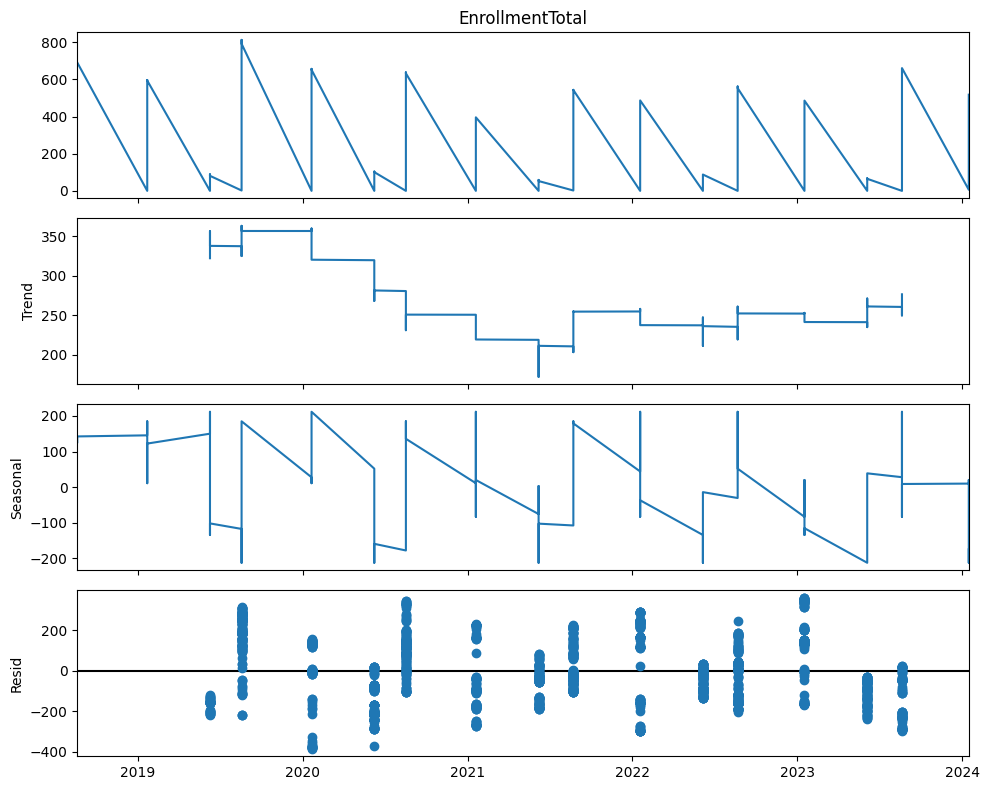

In [ ]:
# Assuming 'df_daily' is your DataFrame and has been properly filtered for MATH 1401
specific_course['StartDate'] = pd.to_datetime(specific_course['StartDate'])
specific_course['CatalogNumber'] = specific_course['CatalogNumber'].astype(int)

# Setting 'StartDate' as the DataFrame index
specific_course.set_index('StartDate', inplace=True)

# Decompose the time series
result = seasonal_decompose(specific_course['EnrollmentTotal'], model='additive', period=365)

# Plotting the decomposed components
fig = result.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()

# Saving the plot as a PNG file
plt.savefig('seasonal_decomposition.png')
plt.show()

**Step 3: Choose Model Type:**



**Step 4: Determining Non-Seasonal Paramters (p,q,d)**

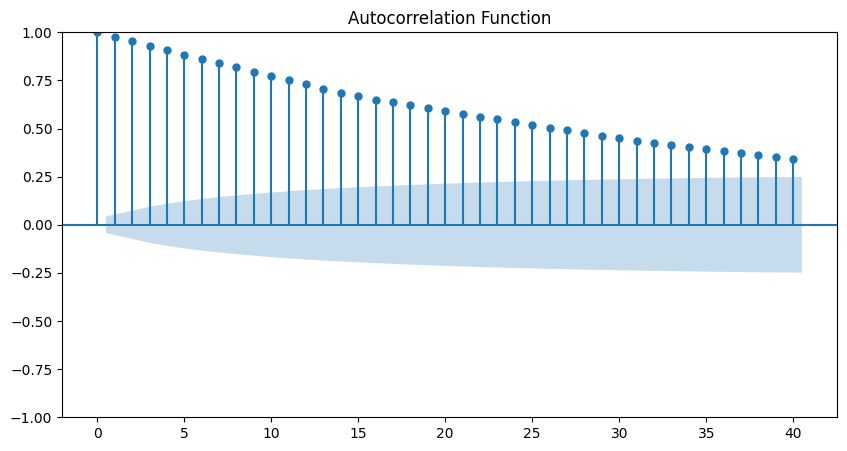

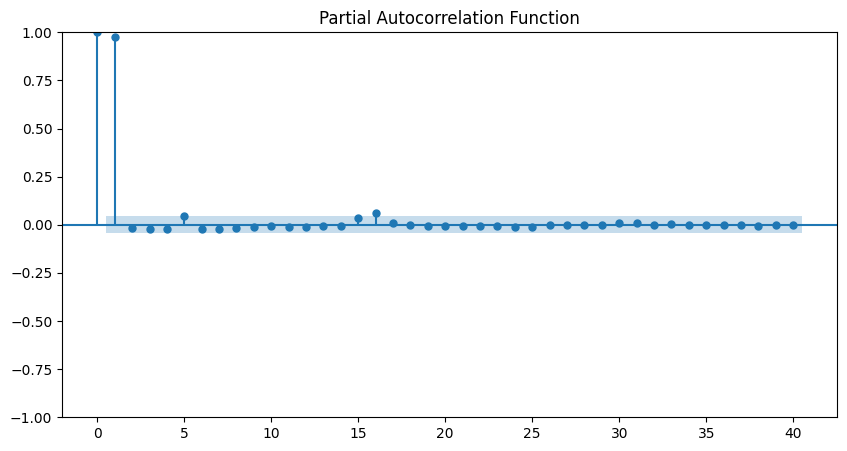

In [ ]:
# Selecting the series you want to analyze
data_series = specific_course['EnrollmentTotal']  # Assuming 'EnrollmentTotal' is your relevant column

# Create figure and axes objects for ACF
fig_acf, ax_acf = plt.subplots(figsize=(10, 5))
plot_acf(data_series, ax=ax_acf, lags=40)  # Adjust the lags as necessary
plt.title('Autocorrelation Function')
plt.savefig('ACF_plot.png')  # Save the ACF plot as a PNG file

# Create figure and axes objects for PACF
fig_pacf, ax_pacf = plt.subplots(figsize=(10, 5))
plot_pacf(data_series, ax=ax_pacf, lags=40)  # Adjust lags similarly
plt.title('Partial Autocorrelation Function')
plt.savefig('PACF_plot.png')  # Save the PACF plot as a PNG file

**Steps 6: Splitting Data into Training Set and Testing Set**

In [ ]:
# Convert 'Timestamp' column to datetime for proper comparison
specific_course['Timestamp'] = pd.to_datetime(specific_course['Timestamp'])

# Split the dataset based on the given date
train_data = specific_course[specific_course['Timestamp'] < "2023-11-01"]
test_data = specific_course[specific_course['Timestamp'] >= "2023-11-01"]

train_data.shape, test_data.shape

<ipython-input-10-8253fcd965a2>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



((1970, 4), (101, 4))

In [ ]:
# Since we are considering a term-based seasonality of 3, let's resample the data by the start of each term.
# We'll approximate the start of each term by resampling every four months starting from January.
term_data = specific_course['EnrollmentTotal'].resample('4M', label='left').mean().dropna()

# Fit the SARIMA(1,0,0)(1,0,0,3) model
model = SARIMAX(term_data, order=(1, 0, 0), seasonal_order=(1, 0, 0, 3), enforce_stationarity=False, enforce_invertibility=False)
results = model.fit()

# Print the model summary
results.summary()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                   EnrollmentTotal   No. Observations:                   12
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 3)   Log Likelihood                 -48.961
Date:                           Thu, 11 Jul 2024   AIC                            103.923
Time:                                   14:27:15   BIC                            104.161
Sample:                                        0   HQIC                           102.315
                                            - 12                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8532      0.160      5.327      0.000       0.539       1.167
ar.S.L3       -0.4304      0.713     -0.603      0.546      -1.828       0.967
sigma2      1.212e+04   9886.413      1.226      0.220   -7259.072    3.15e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.53   Jarque-Bera (JB):                 1.19
Prob(Q):                              0.47   Prob(JB):                         0.55
Heteroskedasticity (H):               0.84   Skew:                            -0.94
Prob(H) (two-sided):                  0.89   Kurtosis:                         3.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Step 9: Model Prediction on the Testing Set**


In [ ]:
# Ensure 'StartDate' and 'Timestamp' are in datetime format
df_daily['StartDate'] = pd.to_datetime(df_daily['StartDate'])
df_daily['Timestamp'] = pd.to_datetime(df_daily['Timestamp'])

# Filter the specific course data
specific_course = df_daily[(df_daily['Subject'] == 'MATH') & (df_daily['CatalogNumber'] == 1401)]

# Ensure 'StartDate' and 'CatalogNumber' columns are correctly set
specific_course.loc[:, 'StartDate'] = pd.to_datetime(specific_course['StartDate'])
specific_course.loc[:, 'CatalogNumber'] = specific_course['CatalogNumber'].astype(int)

# Split the data into training and testing sets
train_data = specific_course[specific_course['Timestamp'] < "2023-11-01"]
test_data = specific_course[specific_course['Timestamp'] >= "2023-11-01"]

# Resample the training data for term-based seasonality
# term_data = train_data.set_index('Timestamp')['EnrollmentTotal'].resample('4M').mean().dropna()

# Fit the SARIMA model
model = SARIMAX(train_data, order=(1, 0, 0), seasonal_order=(1, 0, 0, 4), enforce_stationarity=True, enforce_invertibility=False)
results = model.fit()

# Define prediction dates: Two weeks before StartDate, StartDate, and Census date (15 days after StartDate)
start_date = pd.to_datetime('2024-01-15')
prediction_dates = [
    start_date - pd.Timedelta(weeks=2),
    start_date,
    start_date + pd.Timedelta(days=15)
]

# Get predictions and confidence intervals for the specified dates
predictions = []
for date in prediction_dates:
    prediction = results.get_prediction(start=date, end=date)
    predictions.append(prediction.summary_frame(alpha=0.10))

# Extract means and confidence intervals
prediction_means = [pred_frame['mean'].values[0] for pred_frame in predictions]
prediction_intervals = [(pred_frame['mean_ci_lower'].values[0], pred_frame['mean_ci_upper'].values[0]) for pred_frame in predictions]

# Print out the predictions and their intervals
for i, date in enumerate(prediction_dates):
    print(f"Prediction for {date.date()}:")
    print(f"Mean: {prediction_means[i]}")
    print(f"80% Confidence Interval: {prediction_intervals[i]}")
    print()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(train_data['Timestamp'], train_data['EnrollmentTotal'], label='Training Data', color='blue')
plt.plot(test_data['Timestamp'], test_data['EnrollmentTotal'], label='Actual Test Data', color='green')

# Plot predictions and intervals
for i, date in enumerate(prediction_dates):
    plt.plot(date, prediction_means[i], 'ro', label='Predicted Data' if i == 0 else "")
    plt.errorbar(date, prediction_means[i], yerr=[[prediction_means[i] - prediction_intervals[i][0]], [prediction_intervals[i][1] - prediction_means[i]]], fmt='o', color='red')

plt.title('SARIMA Prediction of EnrollmentTotal (Simplified with CIs)')
plt.xlabel('Timestamp')
plt.ylabel('EnrollmentTotal')
plt.legend()
plt.show()

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [ ]:
print(prediction.summary_frame())

EnrollmentTotal        mean    mean_se  mean_ci_lower  mean_ci_upper
2024-01-31       316.416163  62.941973     193.052163     439.780164


Prediction for 2024-01-01:
Mean: 297.48985081666876
Adjusted 80% Confidence Interval (Bonferroni corrected): (4.587491481780546, 590.392210151557)

Prediction for 2024-01-15:
Mean: 297.48985081666876
Adjusted 80% Confidence Interval (Bonferroni corrected): (4.587491481780546, 590.392210151557)

Prediction for 2024-01-30:
Mean: 297.48985081666876
Adjusted 80% Confidence Interval (Bonferroni corrected): (4.587491481780546, 590.392210151557)



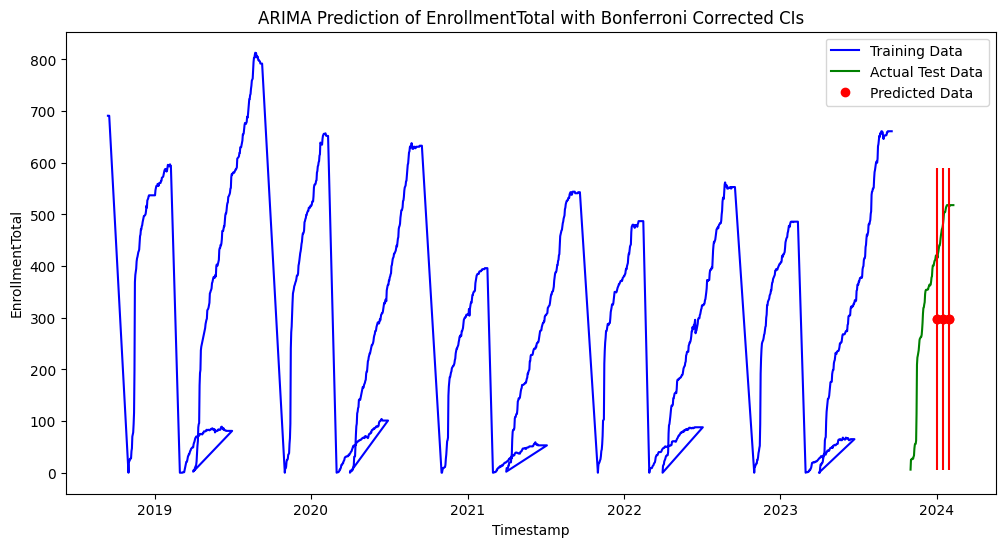

In [ ]:
# Ensure 'StartDate' and 'Timestamp' are in datetime format
df_daily['StartDate'] = pd.to_datetime(df_daily['StartDate'])
df_daily['Timestamp'] = pd.to_datetime(df_daily['Timestamp'])

# Filter the specific course data
specific_course = df_daily[(df_daily['Subject'] == 'MATH') & (df_daily['CatalogNumber'] == 1401)]

# Ensure 'StartDate' and 'CatalogNumber' columns are correctly set
specific_course.loc[:, 'StartDate'] = pd.to_datetime(specific_course['StartDate'])
specific_course.loc[:, 'CatalogNumber'] = specific_course['CatalogNumber'].astype(int)

# Split the data into training and testing sets
train_data = specific_course[specific_course['Timestamp'] < "2023-11-01"]
test_data = specific_course[specific_course['Timestamp'] >= "2023-11-01"]

# Resample the training data for term-based seasonality
term_data = train_data.set_index('Timestamp')['EnrollmentTotal'].resample('4M').mean().dropna()

# Fit the ARIMA model
model = ARIMA(term_data, order=(1, 0, 0))
results = model.fit()

# Define prediction dates: Two weeks before StartDate, StartDate, and Census date (15 days after StartDate)
start_date = pd.to_datetime('2024-01-15')
prediction_dates = [
    start_date - pd.Timedelta(weeks=2),
    start_date,
    start_date + pd.Timedelta(days=15)
]

# Apply Bonferroni correction for 80% overall confidence level
alpha = 0.20 / 3

# Get predictions and confidence intervals for the specified dates
predictions = []
for date in prediction_dates:
    prediction = results.get_prediction(start=date, end=date)
    predictions.append(prediction.summary_frame(alpha=alpha))

# Extract means and confidence intervals
prediction_means = [pred_frame['mean'].values[0] for pred_frame in predictions]
prediction_intervals = [(pred_frame['mean_ci_lower'].values[0], pred_frame['mean_ci_upper'].values[0]) for pred_frame in predictions]

# Print out the predictions and their intervals
for i, date in enumerate(prediction_dates):
    print(f"Prediction for {date.date()}:")
    print(f"Mean: {prediction_means[i]}")
    print(f"Adjusted 80% Confidence Interval (Bonferroni corrected): {prediction_intervals[i]}")
    print()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(train_data['Timestamp'], train_data['EnrollmentTotal'], label='Training Data', color='blue')
plt.plot(test_data['Timestamp'], test_data['EnrollmentTotal'], label='Actual Test Data', color='green')

# Plot predictions and intervals
for i, date in enumerate(prediction_dates):
    plt.plot(date, prediction_means[i], 'ro', label='Predicted Data' if i == 0 else "")
    plt.errorbar(date, prediction_means[i], yerr=[[prediction_means[i] - prediction_intervals[i][0]], [prediction_intervals[i][1] - prediction_means[i]]], fmt='o', color='red')

plt.title('ARIMA Prediction of EnrollmentTotal with Bonferroni Corrected CIs')
plt.xlabel('Timestamp')
plt.ylabel('EnrollmentTotal')
plt.legend()
plt.show()


In [ ]:
# Ensure 'StartDate' and 'Timestamp' are in datetime format
df_daily['StartDate'] = pd.to_datetime(df_daily['StartDate'])
df_daily['Timestamp'] = pd.to_datetime(df_daily['Timestamp'])

# Filter the specific course data
specific_course = df_daily[(df_daily['Subject'] == 'MATH') & (df_daily['CatalogNumber'] == 1401)]

# Ensure 'StartDate' and 'CatalogNumber' columns are correctly set
specific_course.loc[:, 'StartDate'] = pd.to_datetime(specific_course['StartDate'])
specific_course.loc[:, 'CatalogNumber'] = specific_course['CatalogNumber'].astype(int)

# Split the data into training and testing sets
train_data = specific_course[specific_course['Timestamp'] < "2023-11-01"]
test_data = specific_course[specific_course['Timestamp'] >= "2023-11-01"]

# Fit the ARIMA model
model = ARIMA(train_data.set_index('Timestamp')['EnrollmentTotal'], order=(1, 0, 0))
results = model.fit()

# Define prediction dates: Two weeks before StartDate, StartDate, and Census date (15 days after StartDate)
start_date = pd.to_datetime('2024-01-15')
prediction_dates = [
    start_date - pd.Timedelta(weeks=2),
    start_date,
    start_date + pd.Timedelta(days=15)
]

# Apply Bonferroni correction for 80% overall confidence level
alpha = 0.20 / 3

# Get predictions and confidence intervals for the specified dates
predictions = []
for date in prediction_dates:
    prediction = results.get_prediction(start=date, end=date)
    predictions.append(prediction.summary_frame(alpha=alpha))

# Extract means and confidence intervals
prediction_means = [pred_frame['mean'].values[0] for pred_frame in predictions]
prediction_intervals = [(pred_frame['mean_ci_lower'].values[0], pred_frame['mean_ci_upper'].values[0]) for pred_frame in predictions]

# Print out the predictions and their intervals
for i, date in enumerate(prediction_dates):
    print(f"Prediction for {date.date()}:")
    print(f"Mean: {prediction_means[i]}")
    print(f"Adjusted 80% Confidence Interval (Bonferroni corrected): {prediction_intervals[i]}")
    print()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(train_data['Timestamp'], train_data['EnrollmentTotal'], label='Training Data', color='blue')
plt.plot(test_data['Timestamp'], test_data['EnrollmentTotal'], label='Actual Test Data', color='green')

# Plot predictions and intervals
for i, date in enumerate(prediction_dates):
    plt.plot(date, prediction_means[i], 'ro', label='Predicted Data' if i == 0 else "")
    plt.errorbar(date, prediction_means[i], yerr=[[prediction_means[i] - prediction_intervals[i][0]], [prediction_intervals[i][1] - prediction_means[i]]], fmt='o', color='red')

plt.title('ARIMA Prediction of EnrollmentTotal with Bonferroni Corrected CIs')
plt.xlabel('Timestamp')
plt.ylabel('EnrollmentTotal')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency infor

KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'

Prediction for 2024-01-01:
Mean: 316.4161634485033
90% Confidence Interval with Bonferroni correction: (182.47279735679913, 450.3595295402075)

Prediction for 2024-01-15:
Mean: 316.4161634485033
90% Confidence Interval with Bonferroni correction: (182.47279735679913, 450.3595295402075)

Prediction for 2024-01-30:
Mean: 316.4161634485033
90% Confidence Interval with Bonferroni correction: (182.47279735679913, 450.3595295402075)



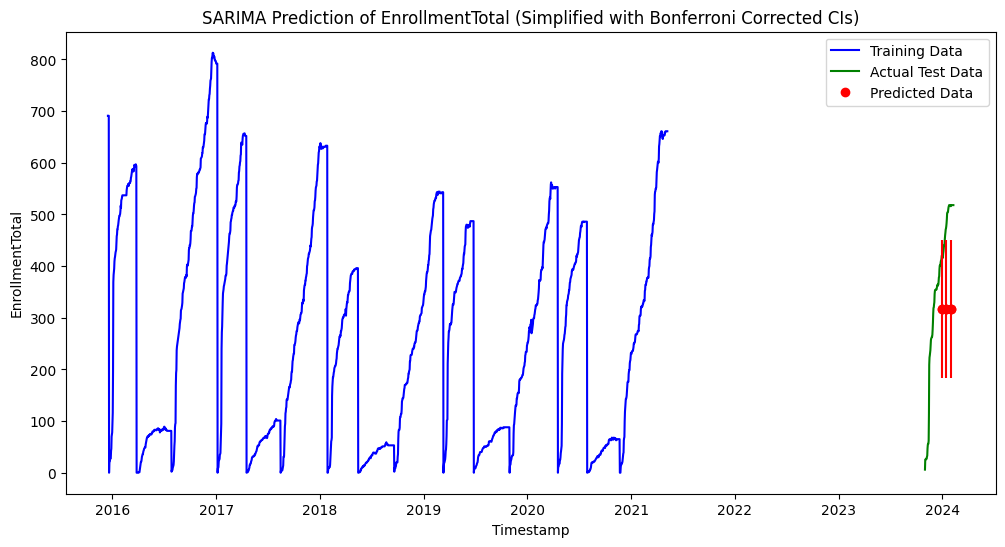

In [ ]:
# Ensure 'StartDate' and 'Timestamp' are in datetime format
df_daily['StartDate'] = pd.to_datetime(df_daily['StartDate'])
df_daily['Timestamp'] = pd.to_datetime(df_daily['Timestamp'])

# Filter the specific course data
specific_course = df_daily[(df_daily['Subject'] == 'MATH') & (df_daily['CatalogNumber'] == 1401)]

# Ensure 'StartDate' and 'CatalogNumber' columns are correctly set
specific_course.loc[:, 'StartDate'] = pd.to_datetime(specific_course['StartDate'])
specific_course.loc[:, 'CatalogNumber'] = specific_course['CatalogNumber'].astype(int)

# Split the data into training and testing sets
train_data = specific_course[specific_course['Timestamp'] < "2023-11-01"]
test_data = specific_course[specific_course['Timestamp'] >= "2023-11-01"]

# Resample the training data for term-based seasonality
term_data = train_data.set_index('Timestamp')['EnrollmentTotal'].resample('4M').mean().dropna()

# Fit the SARIMA model
model = SARIMAX(term_data, order=(1, 0, 0), seasonal_order=(1, 0, 0, 3), enforce_stationarity=False, enforce_invertibility=False)
results = model.fit()

# Define prediction dates: Two weeks before StartDate, StartDate, and Census date (15 days after StartDate)
start_date = pd.to_datetime('2024-01-15')
prediction_dates = [
    start_date - pd.Timedelta(weeks=2),
    start_date,
    start_date + pd.Timedelta(days=15)
]

# Apply Bonferroni correction for alpha
alpha = 0.10 / len(prediction_dates)

# Get predictions and confidence intervals for the specified dates
predictions = []
for date in prediction_dates:
    prediction = results.get_prediction(start=date, end=date)
    predictions.append(prediction.summary_frame(alpha=alpha))

# Extract means and confidence intervals
prediction_means = [pred_frame['mean'].values[0] for pred_frame in predictions]
prediction_intervals = [(pred_frame['mean_ci_lower'].values[0], pred_frame['mean_ci_upper'].values[0]) for pred_frame in predictions]

# Print out the predictions and their intervals
for i, date in enumerate(prediction_dates):
    print(f"Prediction for {date.date()}:")
    print(f"Mean: {prediction_means[i]}")
    print(f"90% Confidence Interval with Bonferroni correction: {prediction_intervals[i]}")
    print()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['EnrollmentTotal'], label='Training Data', color='blue')
plt.plot(test_data['Timestamp'], test_data['EnrollmentTotal'], label='Actual Test Data', color='green')

# Plot predictions and intervals
for i, date in enumerate(prediction_dates):
    plt.plot(date, prediction_means[i], 'ro', label='Predicted Data' if i == 0 else "")
    plt.errorbar(date, prediction_means[i], yerr=[[prediction_means[i] - prediction_intervals[i][0]], [prediction_intervals[i][1] - prediction_means[i]]], fmt='o', color='red')

plt.title('SARIMA Prediction of EnrollmentTotal (Simplified with Bonferroni Corrected CIs)')
plt.xlabel('Timestamp')
plt.ylabel('EnrollmentTotal')
plt.legend()
plt.show()


In [ ]:
–# Ensure 'StartDate' and 'Timestamp' are in datetime format
df_daily['StartDate'] = pd.to_datetime(df_daily['StartDate'])
df_daily['Timestamp'] = pd.to_datetime(df_daily['Timestamp'])

# Filter the specific course data
specific_course = df_daily[(df_daily['Subject'] == 'MATH') & (df_daily['CatalogNumber'] == 1401)]

# Ensure 'StartDate' and 'CatalogNumber' columns are correctly set
specific_course.loc[:, 'StartDate'] = pd.to_datetime(specific_course['StartDate'])
specific_course.loc[:, 'CatalogNumber'] = specific_course['CatalogNumber'].astype(int)

# Split the data into training and testing sets for Fall 2023
train_data = specific_course[(specific_course['Timestamp'] >= "2023-04-01") & (specific_course['Timestamp'] <= "2023-06-15")]
test_data = specific_course[(specific_course['Timestamp'] >= "2023-06-16") & (specific_course['Timestamp'] <= "2023-09-06")]

# Resample the training data for term-based seasonality
term_data = train_data.set_index('Timestamp')['EnrollmentTotal'].resample('4M').mean().dropna()

# Fit the ARIMA model
model = ARIMA(term_data, order=(1, 0, 0))
results = model.fit()

# Define prediction dates: 14 days before the first day of school, first day of school, and census date
start_date = pd.to_datetime('2023-08-21')
prediction_dates = [
    start_date - pd.Timedelta(days=14),  # August 7, 2023
    start_date,                         # August 21, 2023
    pd.to_datetime('2023-09-06')        # September 6, 2023
]

# Apply Bonferroni correction for 80% overall confidence level
alpha = 0.20 / 3

# Get predictions and confidence intervals for the specified dates
predictions = []
for date in prediction_dates:
    prediction = results.get_prediction(start=date, end=date)
    predictions.append(prediction.summary_frame(alpha=alpha))

# Extract means and confidence intervals
prediction_means = [pred_frame['mean'].values[0] for pred_frame in predictions]
prediction_intervals = [(pred_frame['mean_ci_lower'].values[0], pred_frame['mean_ci_upper'].values[0]) for pred_frame in predictions]

# Print out the predictions and their intervals
for i, date in enumerate(prediction_dates):
    print(f"Prediction for {date.date()}:")
    print(f"Mean: {prediction_means[i]}")
    print(f"Adjusted 80% Confidence Interval (Bonferroni corrected): {prediction_intervals[i]}")
    print()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(train_data['Timestamp'], train_data['EnrollmentTotal'], label='Training Data', color='blue')
plt.plot(test_data['Timestamp'], test_data['EnrollmentTotal'], label='Actual Test Data', color='green')

# Plot predictions and intervals
for i, date in enumerate(prediction_dates):
    plt.plot(date, prediction_means[i], 'ro', label='Predicted Data' if i == 0 else "")
    plt.errorbar(date, prediction_means[i], yerr=[[prediction_means[i] - prediction_intervals[i][0]], [prediction_intervals[i][1] - prediction_means[i]]], fmt='o', color='red')

plt.title('ARIMA Prediction of EnrollmentTotal with Bonferroni Corrected CIs for Fall 2023')
plt.xlabel('Timestamp')
plt.ylabel('EnrollmentTotal')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'

**Step 10: Model Diagnostics**
